# LIBRARIES & PATHS

In [12]:
import os

import json
import pandas as pd
from pathlib import Path
import numpy as np

import torch
from torchinfo import summary
import nibabel as nib

from monai.transforms import *
import sys

import seaborn as sns
from sklearn.model_selection import train_test_split

sys.path.append(str(Path.cwd().parent))
from utils.utils import *
from utils.models import *
from utils.augmentation import *

# data directory
DATA_DIR = Path(r"C:\Users\mirko\med_lab\xdata\ATLAS3_Training_Raw")
#) KEY = "bLw,A>?jJ6j6KnV"

## Data extraction and filesystem building

In [13]:
# with tarfile.open(os.path.join(DATA_DIR, "ATLAS_R3.0_raw.tar.gz"), "r:gz") as tar:
#     tar.extractall(os.path.join(DATA_DIR, "xdata/"))

## EDA

### Paths reading

In [14]:
image_paths, mask_paths = t1_masks_path_extractor(data_dir=DATA_DIR)

'image paths' and 'mask paths' lists properly created


### Images orientation distribution

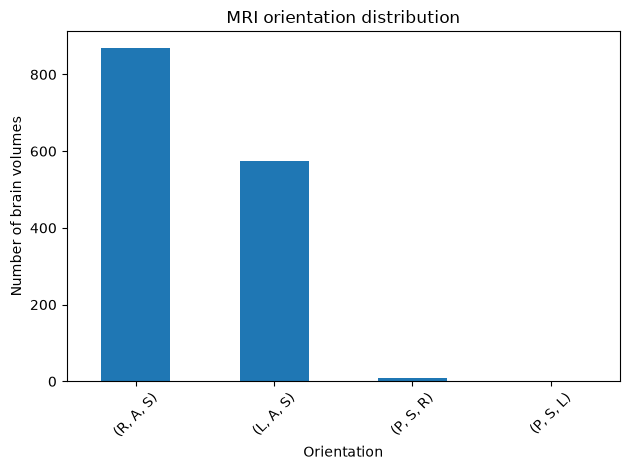

,orientation,relative_freq
0,"(R, A, S)",59.8
1,"(L, A, S)",39.6
2,"(P, S, R)",0.6
3,"(P, S, L)",0.1


In [15]:
df_counts = plot_orient_distr(image_paths=image_paths)
df_counts["relative_freq"] = round(df_counts["count"]/df_counts["count"].sum(),3)*100
df_counts.drop(columns=['count'])

### Shape dimensions variability

In [16]:
shapes = np.array([
    nib.load(p).header.get_data_shape()
    for p in image_paths
])

df_shapes = pd.DataFrame(shapes, columns=["X", "Y", "Z"])
dscr_shapes = df_shapes.describe().round(1)[1:]
dscr_shapes.iloc[2:] = dscr_shapes.iloc[2:].astype(int)
dscr_shapes
# df_shapes.to_csv(r"C:\Users\mirko\med_lab\output\shapes.csv", sep=";", index=False, header=True)

,X,Y,Z
mean,203.8,276.4,268.4
std,59.2,105.9,111.6
min,29.0,70.0,24.0
25%,176.0,225.0,224.0
50%,188.0,256.0,256.0
75%,208.0,256.0,256.0
max,528.0,1008.0,1008.0


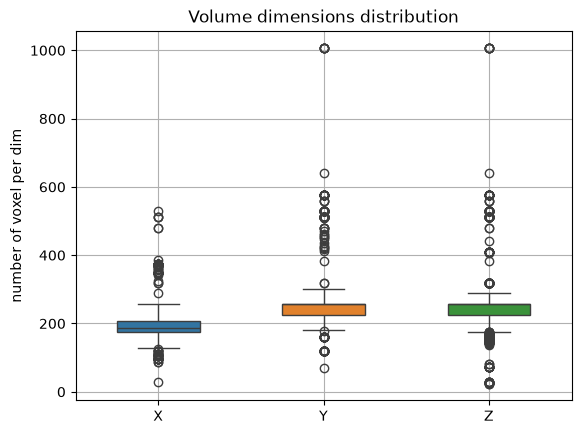

In [17]:
sns.boxplot(data=df_shapes, width=.5)
plt.ylabel("number of voxel per dim")
plt.title("Volume dimensions distribution")
plt.grid(True)
plt.show()

### Pixel dimensions variability

In [18]:
zooms = np.array([
    nib.load(p).header.get_zooms()[:3]
    for p in image_paths
])

df_zooms = pd.DataFrame(zooms, columns=["X", "Y", "Z"])
dscr_zooms = df_zooms.describe().round(3)[1:]
dscr_zooms.iloc[2:] = dscr_zooms.iloc[2:].astype(int)
dscr_zooms

,X,Y,Z
mean,0.968,0.989,0.999
std,0.207,0.381,0.551
min,0.000,0.000,0.000
25%,1.000,1.000,1.000
50%,1.000,1.000,1.000
75%,1.000,1.000,1.000
max,6.000,3.000,6.000


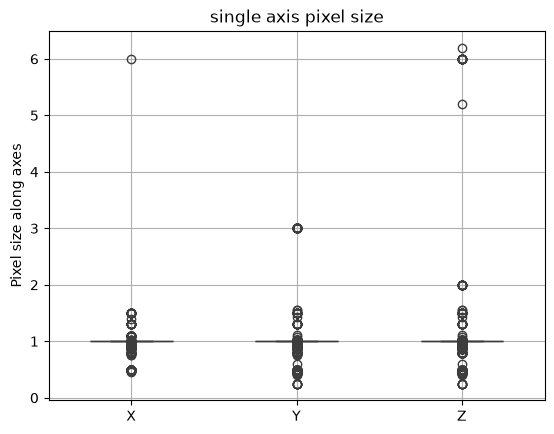

In [19]:
sns.boxplot(data=df_zooms, width=.5)
plt.ylabel("Pixel size along axes")
plt.title("single axis pixel size")
plt.grid(True)
plt.show()

### Check for anisotropy and outliers detection

In [20]:
anisotropy = zooms.max(axis=1) / zooms.min(axis=1)
threshold = 1.5
outliers = np.where(anisotropy > threshold)[0]

print(f"Strong anisotrope images: {len(outliers)} / {len(zooms)}")
print("Examples:")
print(zooms[outliers])
outlier_set = set(outliers)

Strong anisotrope images: 136 / 1453
Examples:
[[0.99999994 0.5        0.5       ]
 [0.99999684 0.5        0.5       ]
 [0.9999983  0.5        0.5       ]
 [0.99999976 0.5        0.5       ]
 [0.99999774 0.5        0.5       ]
 [0.9999937  0.5        0.5       ]
 [1.0000038  0.5        0.5       ]
 [1.0000056  0.5        0.5       ]
 [1.0000037  0.5        0.5       ]
 [0.9999964  0.5        0.5       ]
 [1.0000005  0.5        0.5       ]
 [0.99999523 0.5        0.5       ]
 [1.0000024  0.5        0.5       ]
 [1.         0.5        0.5       ]
 [0.99999905 0.5        0.5       ]
 [1.         0.5        0.5       ]
 [1.0000005  0.5        0.5       ]
 [0.9999946  0.5        0.5       ]
 [0.9999963  0.5        0.5       ]
 [0.9999989  0.5        0.5       ]
 [0.99999803 0.5        0.5       ]
 [0.9999995  0.5        0.5       ]
 [0.9999995  0.5        0.5       ]
 [0.9        0.48828125 0.48828125]
 [0.9        0.48828125 0.48828125]
 [0.9        0.453125   0.453125  ]
 [0.9        0.48

* Since the major part of the images are in a voxel space around (1.0, 1.0, 1.0), with a range of deviation of 0.5, there are cases in which a strong anisotropy is registered.
* In particular, in 136 out of 1453 a max/min ratio of the voxel axes over 1.5 is revealed.

In order to get more robust results, outliers have not been considered for forther analyses.

### Voxels intensity distribution

In [21]:

# voxel_stats = []

# for p in image_paths:
#     img = nib.load(p)
#     data = img.get_fdata(dtype=np.float32)

#     voxel_stats.append({
#         "min": np.min(data),
#         "max": np.max(data),
#         "mean": np.mean(data),
#         "std": np.std(data),
#         "p1": np.percentile(data, 1),
#         "p99": np.percentile(data, 99)
#     })

# voxel_stats = pd.DataFrame(voxel_stats)
# voxel_stats.to_csv(r"C:\Users\mirko\med_lab\output\voxel_stats.csv", sep=";", index=False, header=True)


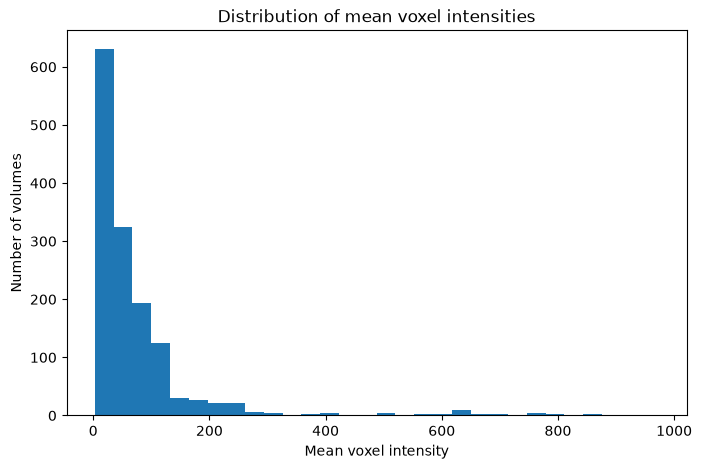

In [22]:
voxel_stats = pd.read_csv(r"C:\Users\mirko\med_lab\output\voxel_stats.csv", sep=';', low_memory=False)
voxel_stats_filtered = voxel_stats[voxel_stats["mean"] <= 2000]
plt.figure(figsize=(8,5))

plt.hist(
    voxel_stats_filtered["mean"] ,
    bins=30,
    edgecolor=None
)

plt.xlabel("Mean voxel intensity")
plt.ylabel("Number of volumes")
plt.title("Distribution of mean voxel intensities")

plt.show()

# WORKING DATASET

In [23]:
dataset = [
    {"image": img, "label": mask}
    for img, mask in zip(image_paths, mask_paths)
]

dataset_clean = [
    item
    for idx, item in enumerate(dataset)
    if idx not in outlier_set
]

# PREPROCESSING PIPELINE & DATA LOADING

## Compose architectures

Three different preprocessing workflows are proposed:
* `base_transforms` represent deterministic operations performed over validation and test set:
* `train_randcrop_transforms` add the Random Crop by patches extraction technique, performed over the train data:
* `train_augm_transforms` is the preprocessing pipeline performed on the train data with augmentation steps tuned with random search of best parameter values.

In [24]:
base_transforms = Compose([
    LoadImaged(keys=["image", "label"]),
    EnsureChannelFirstd(keys=["image", "label"]),
    Orientationd(keys=["image", "label"], axcodes="RAS"),
    Spacingd(keys=["image", "label"], pixdim=(1.0, 1.0, 1.0), mode=("bilinear", "nearest")),
    CropForegroundd(keys=["image", "label"], source_key="image", margin=10),
    NormalizeIntensityd(keys=["image"], nonzero=True),
    EnsureTyped(keys=["image", "label"])
])

c:\Users\mirko\miniconda3\envs\medenv\Lib\site-packages\monai\utils\deprecate_utils.py:321: FutureWarning: monai.transforms.spatial.dictionary Orientationd.__init__:labels: Current default value of argument `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` was changed in version None from `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` to `labels=None`. Default value changed to None meaning that the transform now uses the 'space' of a meta-tensor, if applicable, to determine appropriate axis labels.
  warn_deprecated(argname, msg, warning_category)


In [25]:
train_randcrop_transforms = Compose([
    LoadImaged(keys=["image", "label"]),
    EnsureChannelFirstd(keys=["image", "label"]),
    Orientationd(keys=["image", "label"], axcodes="RAS"),
    Spacingd(keys=["image", "label"], pixdim=(1.0, 1.0, 1.0), mode=("bilinear", "nearest")),
    CropForegroundd(keys=["image", "label"], source_key="image", margin=10),
    NormalizeIntensityd(keys=["image"], nonzero=True),
    RandCropByPosNegLabeld(keys=["image","label"],label_key="label",spatial_size=(128,128,64),pos=1,neg=1,num_samples=4),
    EnsureTyped(keys=["image", "label"])
])

In [26]:
with open(r"C:\Users\mirko\med_lab\notebook\best_augm_param.json", "r") as f:
    best_params = json.load(f)
pos, neg = best_params["pos_neg"]

train_augm_transforms =  Compose([
        LoadImaged(keys=["image", "label"]),
        EnsureChannelFirstd(keys=["image", "label"]),
        Orientationd(keys=["image", "label"], axcodes="RAS"),
        Spacingd(keys=["image", "label"], pixdim=(1.0,1.0,1.0), mode=("bilinear","nearest")),
        CropForegroundd(keys=["image","label"], source_key="image", margin=best_params["margin"]),
        NormalizeIntensityd(keys=["image"], nonzero=True),
        SpatialPadd(keys=["image", "label"], spatial_size=(128, 128, 64)),
        RandCropByPosNegLabeld(keys=["image","label"], label_key="label", spatial_size=(128,128,64), 
                               pos=pos, neg=neg,  
                               num_samples=best_params["num_samples"]),
        RandFlipd(keys=["image","label"], prob=best_params["flip_prob"], spatial_axis=0),
        RandFlipd(keys=["image","label"], prob=best_params["flip_prob"], spatial_axis=1),
        RandAffined(keys=["image","label"], prob=best_params["affine_prob"], 
                    rotate_range=best_params["rotate_range"], scale_range=best_params["scale_range"], 
                    translate_range=best_params["translate_range"], mode=("bilinear","nearest")),
        RandGaussianNoised(keys=["image"], prob=best_params["noise_prob"], mean=0.0, std=best_params["noise_std"]),
        RandAdjustContrastd(keys=["image"], prob=best_params["contrast_prob"], gamma=best_params["gamma"]),
        EnsureTyped(keys=["image","label"])
    ])


## Train val test split and Data loaders

In [27]:
_, train_loader, val_loader, test_loader = build_train_val_test_loaders(data=dataset_clean[:100],
                                                                        base_transforms=base_transforms,
                                                                        train_augm_transforms=train_augm_transforms)

Loading dataset:   0%|          | 0/80 [00:00<?, ?it/s]

Loading dataset: 100%|██████████| 80/80 [00:24<00:00,  3.21it/s]
c:\Users\mirko\miniconda3\envs\medenv\Lib\site-packages\monai\data\dataset.py:1052: UserWarning: cache_num is greater or equal than dataset length, fall back to regular monai.data.CacheDataset.
  warnings.warn(
Loading dataset: 100%|██████████| 10/10 [00:02<00:00,  3.90it/s]
c:\Users\mirko\miniconda3\envs\medenv\Lib\site-packages\monai\data\dataset.py:1052: UserWarning: cache_num is greater or equal than dataset length, fall back to regular monai.data.CacheDataset.
  warnings.warn(
Loading dataset: 100%|██████████| 10/10 [00:03<00:00,  2.74it/s]
c:\Users\mirko\miniconda3\envs\medenv\Lib\site-packages\monai\data\dataset.py:1052: UserWarning: cache_num is greater or equal than dataset length, fall back to regular monai.data.CacheDataset.
  warnings.warn(


# MODEL TRAINING

In [17]:
model, loss_fn, optimizer = unet_model()

_ = training_eval_loop(
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    model=model,
    loss_fn=loss_fn,
    optimizer=optimizer,
    NUM_EPOCHS=50,
    resume_checkpoint=None
)

c:\Users\mirko\miniconda3\envs\medenv\Lib\site-packages\monai\transforms\utils.py:679: UserWarning: Num foregrounds 0, Num backgrounds 5214495, unable to generate class balanced samples, setting `pos_ratio` to 0.
  warnings.warn(
c:\Users\mirko\miniconda3\envs\medenv\Lib\site-packages\monai\transforms\utils.py:679: UserWarning: Num foregrounds 0, Num backgrounds 5101512, unable to generate class balanced samples, setting `pos_ratio` to 0.
  warnings.warn(



Epoch 1/50
Train Loss: 1.1890
Val Loss:   0.9716
Val Dice:   0.0000
💾 Best model salvato!
💾 Checkpoint aggiornato!

Epoch 2/50
Train Loss: 0.9767
Val Loss:   0.9554
Val Dice:   0.0000
💾 Checkpoint aggiornato!

Epoch 3/50
Train Loss: 0.9256
Val Loss:   0.9094
Val Dice:   0.0000
💾 Checkpoint aggiornato!

Epoch 4/50
Train Loss: 0.8831
Val Loss:   0.8001
Val Dice:   0.2673
💾 Best model salvato!
💾 Checkpoint aggiornato!

Epoch 5/50
Train Loss: 0.7974
Val Loss:   0.6861
Val Dice:   0.3663
💾 Best model salvato!
💾 Checkpoint aggiornato!

Epoch 6/50
Train Loss: 0.7588
Val Loss:   0.6878
Val Dice:   0.3594
💾 Checkpoint aggiornato!

Epoch 7/50
Train Loss: 0.7303
Val Loss:   0.6118
Val Dice:   0.4304
💾 Best model salvato!
💾 Checkpoint aggiornato!

Epoch 8/50
Train Loss: 0.7054
Val Loss:   0.6605
Val Dice:   0.3820
💾 Checkpoint aggiornato!

Epoch 9/50
Train Loss: 0.6907
Val Loss:   0.5624
Val Dice:   0.4760
💾 Best model salvato!
💾 Checkpoint aggiornato!

Epoch 10/50
Train Loss: 0.6805
Val Loss:   

Spacingd:
* **bilinear** interpolation is used for t1 images: resample is run by averaging continous voxels. For instance, to enlarge (1.0 , 2.0) into 3 voxels, it is obtained (1.0, 1.5, 2.0)
* **nearest** interpolation is used for masks: in this case, as mask takes into account binary integers, enlarging the voxel space is performed by chosing the nearest value. For instance to enlarge to the right (0,1) -> (0,1,1)

CropForeground:
* remove out-of-interest voxels, when black frame is large enough. It results in a zoomed-like brain image

NormalizeIntensityd:
* scale voxel values based on mean and std (`subtrahend=None`)
* `nonzero=True` applies normalization by considering nonzero voxels as well, with the result of obtaining lightened frame
* `channel_wise=True` applies normalization by computing mean/std for each single channel separately. Otherwise, global mean/std would be computed with the result of a global normalization. In my case, having a single channel, this param is irrelevant.


#### random search params tuning loop

In [ ]:
"""
best_dice = -1
best_params = None

for i in range(20):

    params, train_loader, val_loader, test_loader = build_train_val_test_loaders(
        data=dataset_clean[:900],
        base_transforms=base_transforms
    )

    model, loss_fn, optimizer = unet_model()

    test_dice = training_eval_loop(
        train_loader=train_loader,
        val_loader=val_loader,
        test_loader=test_loader,
        model=model,
        loss_fn=loss_fn,
        optimizer=optimizer,
        NUM_EPOCHS=5,
        resume_checkpoint=None
    )

    if test_dice > best_dice:
        best_dice = test_dice
        best_params = params
        print(f"New best Dice: {best_dice:.4f}")

print("\n=== END OF RANDOM SEARCH ===")
print(f"Best Dice: {best_dice:.4f}")
print(best_params)

with open("best_augm_param.json", "w", encoding="utf-8") as f:
    json.dump(best_params, f, indent=4, ensure_ascii=False)
"""

Loading dataset: 100%|██████████| 720/720 [04:11<00:00,  2.86it/s]
c:\Users\mirko\miniconda3\envs\medenv\Lib\site-packages\monai\data\dataset.py:1052: UserWarning: cache_num is greater or equal than dataset length, fall back to regular monai.data.CacheDataset.
  warnings.warn(
Loading dataset: 100%|██████████| 90/90 [00:32<00:00,  2.77it/s]
c:\Users\mirko\miniconda3\envs\medenv\Lib\site-packages\monai\data\dataset.py:1052: UserWarning: cache_num is greater or equal than dataset length, fall back to regular monai.data.CacheDataset.
  warnings.warn(
Loading dataset: 100%|██████████| 90/90 [00:31<00:00,  2.86it/s]
c:\Users\mirko\miniconda3\envs\medenv\Lib\site-packages\monai\data\dataset.py:1052: UserWarning: cache_num is greater or equal than dataset length, fall back to regular monai.data.CacheDataset.
  warnings.warn(
c:\Users\mirko\miniconda3\envs\medenv\Lib\site-packages\monai\transforms\utils.py:679: UserWarning: Num foregrounds 0, Num backgrounds 4377296, unable to generate class b


Epoch 1/5
Train Loss: 1.3377
Val Loss:   1.0317
Val Dice:   0.0000
💾 Best model salvato!
💾 Checkpoint aggiornato!

Epoch 2/5
Train Loss: 1.0212
Val Loss:   0.9723
Val Dice:   0.0000
💾 Checkpoint aggiornato!

Epoch 3/5
Train Loss: 0.9703
Val Loss:   0.9292
Val Dice:   0.0000
💾 Checkpoint aggiornato!

Epoch 4/5
Train Loss: 0.9278
Val Loss:   0.9385
Val Dice:   0.0089
💾 Best model salvato!
💾 Checkpoint aggiornato!

Epoch 5/5
Train Loss: 0.9033
Val Loss:   0.8777
Val Dice:   0.1983
💾 Best model salvato!
💾 Checkpoint aggiornato!


c:\Users\mirko\miniconda3\envs\medenv\Lib\site-packages\monai\utils\deprecate_utils.py:321: FutureWarning: monai.transforms.spatial.dictionary Orientationd.__init__:labels: Current default value of argument `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` was changed in version None from `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` to `labels=None`. Default value changed to None meaning that the transform now uses the 'space' of a meta-tensor, if applicable, to determine appropriate axis labels.
  warn_deprecated(argname, msg, warning_category)



Best Validation Dice: 0.1983
Test Loss:            0.8933
Test Dice:            0.1730
New best Dice: 0.1730


Loading dataset: 100%|██████████| 720/720 [04:21<00:00,  2.75it/s]
c:\Users\mirko\miniconda3\envs\medenv\Lib\site-packages\monai\data\dataset.py:1052: UserWarning: cache_num is greater or equal than dataset length, fall back to regular monai.data.CacheDataset.
  warnings.warn(
Loading dataset: 100%|██████████| 90/90 [00:31<00:00,  2.82it/s]
c:\Users\mirko\miniconda3\envs\medenv\Lib\site-packages\monai\data\dataset.py:1052: UserWarning: cache_num is greater or equal than dataset length, fall back to regular monai.data.CacheDataset.
  warnings.warn(
Loading dataset: 100%|██████████| 90/90 [00:32<00:00,  2.74it/s]
c:\Users\mirko\miniconda3\envs\medenv\Lib\site-packages\monai\data\dataset.py:1052: UserWarning: cache_num is greater or equal than dataset length, fall back to regular monai.data.CacheDataset.
  warnings.warn(
c:\Users\mirko\miniconda3\envs\medenv\Lib\site-packages\monai\transforms\utils.py:679: UserWarning: Num foregrounds 0, Num backgrounds 5233896, unable to generate class b

...


Epoch 1/5
Train Loss: 1.3477
Val Loss:   1.0451
Val Dice:   0.0000
💾 Best model salvato!
💾 Checkpoint aggiornato!

Epoch 2/5
Train Loss: 1.0205
Val Loss:   0.9789
Val Dice:   0.0000
💾 Checkpoint aggiornato!

Epoch 3/5
Train Loss: 0.9660
Val Loss:   0.9175
Val Dice:   0.0000
💾 Checkpoint aggiornato!

Epoch 4/5
Train Loss: 0.9188
Val Loss:   0.9243
Val Dice:   0.0008
💾 Best model salvato!
💾 Checkpoint aggiornato!

Epoch 5/5
Train Loss: 0.8879
Val Loss:   0.8438
Val Dice:   0.2308
💾 Best model salvato!
💾 Checkpoint aggiornato!


c:\Users\mirko\miniconda3\envs\medenv\Lib\site-packages\monai\utils\deprecate_utils.py:321: FutureWarning: monai.transforms.spatial.dictionary Orientationd.__init__:labels: Current default value of argument `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` was changed in version None from `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` to `labels=None`. Default value changed to None meaning that the transform now uses the 'space' of a meta-tensor, if applicable, to determine appropriate axis labels.
  warn_deprecated(argname, msg, warning_category)



Best Validation Dice: 0.2308
Test Loss:            0.8695
Test Dice:            0.1886


Loading dataset: 100%|██████████| 720/720 [04:16<00:00,  2.81it/s]
c:\Users\mirko\miniconda3\envs\medenv\Lib\site-packages\monai\data\dataset.py:1052: UserWarning: cache_num is greater or equal than dataset length, fall back to regular monai.data.CacheDataset.
  warnings.warn(
Loading dataset: 100%|██████████| 90/90 [00:32<00:00,  2.77it/s]
c:\Users\mirko\miniconda3\envs\medenv\Lib\site-packages\monai\data\dataset.py:1052: UserWarning: cache_num is greater or equal than dataset length, fall back to regular monai.data.CacheDataset.
  warnings.warn(
Loading dataset: 100%|██████████| 90/90 [00:31<00:00,  2.87it/s]
c:\Users\mirko\miniconda3\envs\medenv\Lib\site-packages\monai\data\dataset.py:1052: UserWarning: cache_num is greater or equal than dataset length, fall back to regular monai.data.CacheDataset.
  warnings.warn(
c:\Users\mirko\miniconda3\envs\medenv\Lib\site-packages\monai\transforms\utils.py:679: UserWarning: Num foregrounds 0, Num backgrounds 3619296, unable to generate class b


Epoch 1/5
Train Loss: 1.3276
Val Loss:   1.0372
Val Dice:   0.0000
💾 Best model salvato!
💾 Checkpoint aggiornato!

Epoch 2/5
Train Loss: 1.0230
Val Loss:   0.9570
Val Dice:   0.0000
💾 Checkpoint aggiornato!

Epoch 3/5
Train Loss: 0.9615
Val Loss:   0.9179
Val Dice:   0.0000
💾 Checkpoint aggiornato!

Epoch 4/5
Train Loss: 0.9107
Val Loss:   0.9531
Val Dice:   0.1386
💾 Best model salvato!
💾 Checkpoint aggiornato!

Epoch 5/5
Train Loss: 0.8756
Val Loss:   0.8545
Val Dice:   0.2175
💾 Best model salvato!
💾 Checkpoint aggiornato!

Best Validation Dice: 0.2175
Test Loss:            0.8715
Test Dice:            0.1954

=== END OF RANDOM SEARCH ===
Best Dice: 0.2310
{'margin': 10, 'pos_neg': (1, 1), 'num_samples': 6, 'flip_prob': 0.4, 'affine_prob': 0.3, 'rotate_range': (0.08, 0.08, 0.08), 'scale_range': (0.02, 0.02, 0.02), 'translate_range': (8, 8, 5), 'noise_prob': 0.3, 'noise_std': 0.03, 'contrast_prob': 0.3, 'gamma': (0.9, 1.1)}


# RESULTS VIDUALIZATION

## Simple model

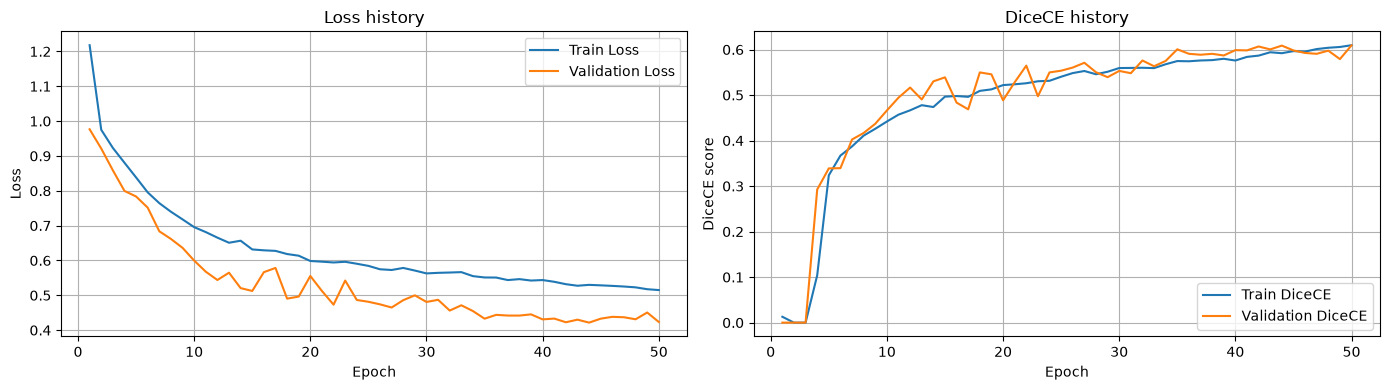

In [2]:
show_loss_eval_metric_history(r"C:\Users\mirko\med_lab\results\history_simple_model.pth")

## Augmented model

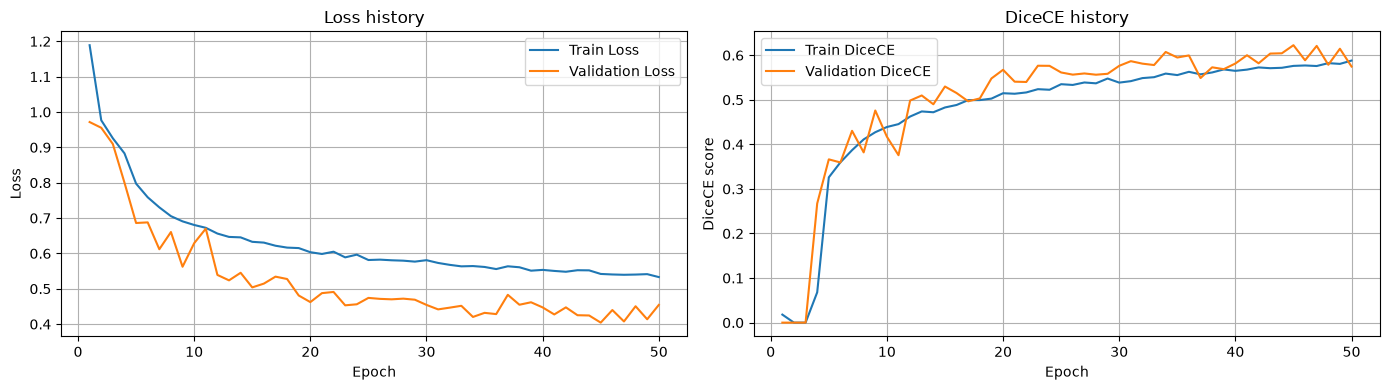

In [2]:
show_loss_eval_metric_history(r"C:\Users\mirko\med_lab\results\history_augm_model.pth")